<h1>Homework 3</h1>

<p>We estimate a cubic cost function in this homework. We also print out the 
descriptive statistics, correlations, and parameter estimates. We also plot the
data.</p>

In [1]:
# -----------------------------------------------------------
# HOMEWORK 3: CUBIC COST FUNCTION ESTIMATION
# -----------------------------------------------------------
# This program:
# 1. Loads production and cost data
# 2. Creates polynomial terms (Q^2 and Q^3)
# 3. Displays descriptive statistics
# 4. Examines correlation among polynomial terms
# 5. Estimates a cubic cost function
# 6. Plots Total Cost vs Quantity with fitted curve
# -----------------------------------------------------------

# -----------------------------------------------------------
# STEP 1: IMPORT LIBRARIES
# -----------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Regression library
from statsmodels.formula.api import ols

# -----------------------------------------------------------
# STEP 2: LOAD THE DATA
# -----------------------------------------------------------

df = pd.read_csv('Cubic_cost_function.csv')

# Preview the data
print(df.head())


   Quantity   Total_Cost
0         1   902.581322
1         2   400.268559
2         3  1035.220830
3         4  1742.263885
4         5   343.927300


<p>We display the descriptive statistics. We normally do not display calculated variables.</p>

In [2]:
# -----------------------------------------------------------
# STEP 3: CREATE POLYNOMIAL TERMS
# -----------------------------------------------------------
# These allow us to estimate a cubic cost function

df['Q_squared'] = df['Quantity'] ** 2
df['Q_cubed'] = df['Quantity'] ** 3

# -----------------------------------------------------------
# STEP 4: DESCRIPTIVE STATISTICS (ONLY Q AND COSTS)
# -----------------------------------------------------------

stats = df[['Quantity', 'Total_Cost']]

desc_stats = stats.describe().T
desc_stats.rename(columns={
    'count': 'Count',
    'mean': 'Mean',
    'std': 'Std Dev',
    'min': 'Min',
    '25%': '25%',
    '50%': 'Median',
    '75%': '75%',
    'max': 'Max'
}, inplace=True)

desc_stats = desc_stats.round(3)

print('\n----- DESCRIPTIVE STATISTICS (Q & COSTS) -----')
print(desc_stats)



----- DESCRIPTIVE STATISTICS (Q & COSTS) -----
            Count      Mean   Std Dev    Min      25%    Median       75%  \
Quantity    100.0    50.500    29.011  1.000   25.750    50.500    75.250   
Total_Cost  100.0  3924.022  3703.591  9.371  889.031  2644.829  6636.278   

                 Max  
Quantity      100.00  
Total_Cost  12812.33  


<p>Print out the correlation matrix as a heatmap.</p>


----- CORRELATION MATRIX (Total_Cost, Q, Q^2, Q^3) -----
            Total_Cost  Quantity  Q_squared   Q_cubed
Total_Cost    1.000000  0.914236   0.975385  0.981617
Quantity      0.914236  1.000000   0.968854  0.917552
Q_squared     0.975385  0.968854   1.000000  0.986087
Q_cubed       0.981617  0.917552   0.986087  1.000000


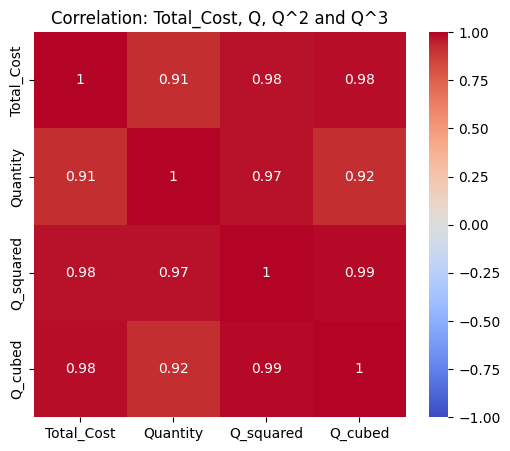

In [3]:
# -----------------------------------------------------------
# STEP 5: CORRELATION MATRIX (Total_Cost, Q, Q^2, AND Q^3 ONLY)
# -----------------------------------------------------------

poly_vars = df[['Total_Cost','Quantity','Q_squared', 'Q_cubed']]

corr_poly = poly_vars.corr()

print('\n----- CORRELATION MATRIX (Total_Cost, Q, Q^2, Q^3) -----')
print(corr_poly)

# Optional heatmap (nice visual)
plt.figure(figsize=(6, 5))
sns.heatmap(corr_poly, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation: Total_Cost, Q, Q^2 and Q^3')
plt.show()


<p>Estimate the Total Cost Function.</p>

In [4]:
# -----------------------------------------------------------
# STEP 6: ESTIMATE THE CUBIC COST FUNCTION
# -----------------------------------------------------------
# Cost = β0 + β1*Q + β2*Q^2 + β3*Q^3

model = ols('Total_Cost ~ Quantity + Q_squared + Q_cubed', data=df).fit()

print('\n----- CUBIC COST FUNCTION RESULTS -----')
print(model.summary())



----- CUBIC COST FUNCTION RESULTS -----
                            OLS Regression Results                            
Dep. Variable:             Total_Cost   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     937.0
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           6.22e-71
Time:                        13:42:16   Log-Likelihood:                -792.57
No. Observations:                 100   AIC:                             1593.
Df Residuals:                      96   BIC:                             1604.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  

<p>Plot the actual costs and predicted costs.</p>

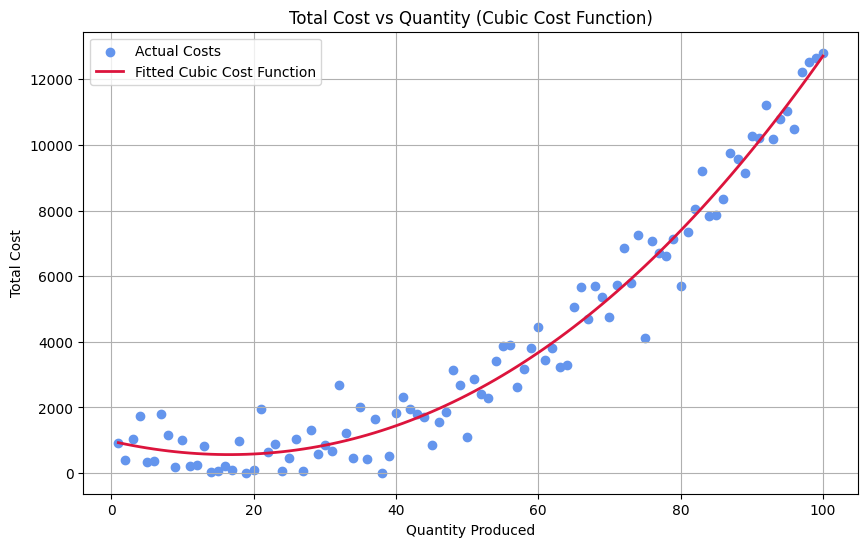

In [5]:
# -----------------------------------------------------------
# STEP 7: PLOT TOTAL COST VS QUANTITY
# -----------------------------------------------------------

# Generate predicted costs
df['Costs_pred'] = model.predict(df[['Quantity', 'Q_squared', 'Q_cubed']])

# Sort values for smooth curve
df_sorted = df.sort_values(by='Quantity')

# Create the plot
plt.figure(figsize=(10, 6))

# Scatter plot (actual data)
plt.scatter(df['Quantity'], df['Total_Cost'],
            color='cornflowerblue',
            label='Actual Costs')

# Fitted curve
plt.plot(df_sorted['Quantity'], df_sorted['Costs_pred'],
         color='crimson',
         linewidth=2,
         label='Fitted Cubic Cost Function')

# Labels and title
plt.xlabel('Quantity Produced')
plt.ylabel('Total Cost')
plt.title('Total Cost vs Quantity (Cubic Cost Function)')

# Legend and grid
plt.legend()
plt.grid()

# Show plot
plt.show()